<a href="https://colab.research.google.com/github/fitridianamusa/Artikel-ADW-Kelompok-8/blob/main/Progres_1_Koding_Artikel_ADW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Progres 1 Artikel ADW

## Load Data

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/fitridianamusa/Artikel-ADW-Kelompok-8/main/Data%20Historis%20USD_IDR.csv"

kurs = pd.read_csv(url)

kurs.head()

,Tanggal,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%
0,01/09/2026,"17.715,0","17.725,0","17.735,0","17.704,5",NaN,"0,00%"
1,31/08/2026,"17.715,0","17.750,0","17.770,0","17.712,5",NaN,"0,14%"
2,28/08/2026,"17.690,0","17.715,0","17.722,5","17.679,0",NaN,"-0,17%"
3,27/08/2026,"17.720,0","17.760,0","17.790,0","17.720,0",NaN,"0,11%"
4,26/08/2026,"17.700,0","17.695,0","17.733,5","17.677,5",NaN,"-0,06%"


In [2]:
# Lihat Tipe Data Awal
kurs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1442 entries, 0 to 1441
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Tanggal     1442 non-null   object
 1   Terakhir    1442 non-null   object
 2   Pembukaan   1442 non-null   object
 3   Tertinggi   1442 non-null   object
 4   Terendah    1442 non-null   object
 5   Vol.        502 non-null    object
 6   Perubahan%  1442 non-null   object
dtypes: object(7)
memory usage: 79.0+ KB


In [3]:
# Cleaning Data
# Ambil hanya kolom yang digunakan
kurs = kurs[['Tanggal', 'Terakhir']].copy()

# Ubah Tanggal menjadi datetime
kurs['Tanggal'] = pd.to_datetime(
    kurs['Tanggal'],
    dayfirst=True,
    errors='coerce'
)

# Bersihkan kolom Terakhir
kurs['Terakhir'] = (
    kurs['Terakhir']
    .astype(str)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
)

# Ubah menjadi numerik
kurs['Terakhir'] = pd.to_numeric(
    kurs['Terakhir'],
    errors='coerce'
)

In [4]:
# Pengecekan ulang tipe data setelah cleaning
kurs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1442 entries, 0 to 1441
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Tanggal   1442 non-null   datetime64[ns]
 1   Terakhir  1442 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 22.7 KB


In [5]:
kurs.head()

,Tanggal,Terakhir
0,2026-09-01,17715.0
1,2026-08-31,17715.0
2,2026-08-28,17690.0
3,2026-08-27,17720.0
4,2026-08-26,17700.0


In [6]:
import pandas as pd

# Mengurutkan ulang deret waktu dari terlama ke terbaru
kurs = kurs.sort_values('Tanggal').reset_index(drop=True)

# Menampilkan 5 data pertama
kurs.head()

,Tanggal,Terakhir
0,2021-01-01,14213.7
1,2021-01-04,13885.0
2,2021-01-05,13900.0
3,2021-01-06,13880.0
4,2021-01-07,13890.0


In [7]:
# Cek jumlah tanggal yang duplikat
kurs.duplicated(subset='Tanggal').sum()

np.int64(0)

In [8]:
# Ngecek Missing Value
kurs.isnull().sum()

,0
Tanggal,0
Terakhir,0


## Plot Time Series Data

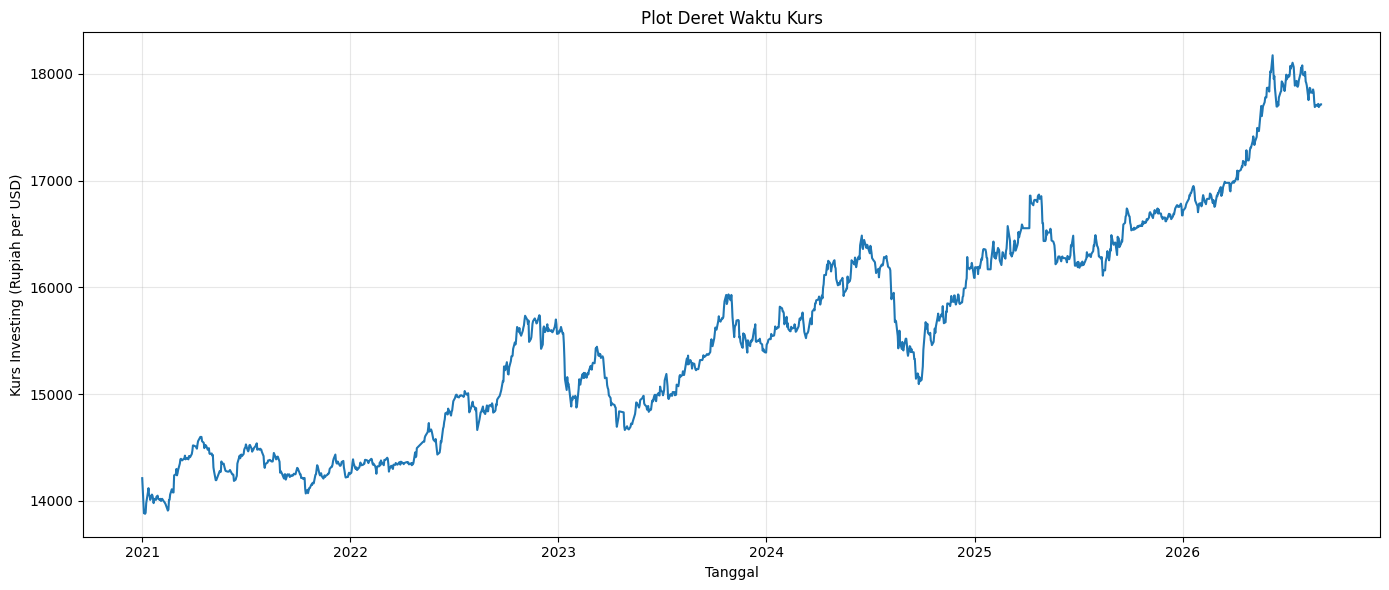

In [9]:
# Menampilkan Plot Time Series Data Kurs
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(kurs['Tanggal'], kurs['Terakhir'])

plt.title('Plot Deret Waktu Kurs')
plt.xlabel('Tanggal')
plt.ylabel('Kurs Investing (Rupiah per USD)')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Membuat Log Return
Data diubah menjadi log return karena GARCH biasanya memodelkan perubahan nilai kurs, bukan level kursnya langsung.

Persamaan log return:

$$
r_t = 100\ln\left(\frac{P_t}{P_{t-1}}\right)
$$

In [10]:
import numpy as np

# Menghitung log return dalam persen
kurs['Return'] = 100 * np.log(
    kurs['Terakhir'] / kurs['Terakhir'].shift(1)
)

# Melihat hasil
kurs[['Tanggal', 'Terakhir', 'Return']].head()

,Tanggal,Terakhir,Return
0,2021-01-01,14213.7,NaN
1,2021-01-04,13885.0,-2.339717
2,2021-01-05,13900.0,0.107972
3,2021-01-06,13880.0,-0.143989
4,2021-01-07,13890.0,0.072020


Data pertama pada kolom Return menjadi NaN. Itu normal, karena pada observasi pertama tidak ada nilai kurs sebelumnya.

Kemudian, baris pertama dari amatan tersebut akan dihapus.

In [11]:
# Menghapus baris pertama data hasil log return
kurs_return = kurs.dropna(subset=['Return']).copy()

kurs_return[['Tanggal', 'Terakhir', 'Return']].head()

,Tanggal,Terakhir,Return
1,2021-01-04,13885.0,-2.339717
2,2021-01-05,13900.0,0.107972
3,2021-01-06,13880.0,-0.143989
4,2021-01-07,13890.0,0.072020
5,2021-01-08,13980.0,0.645858


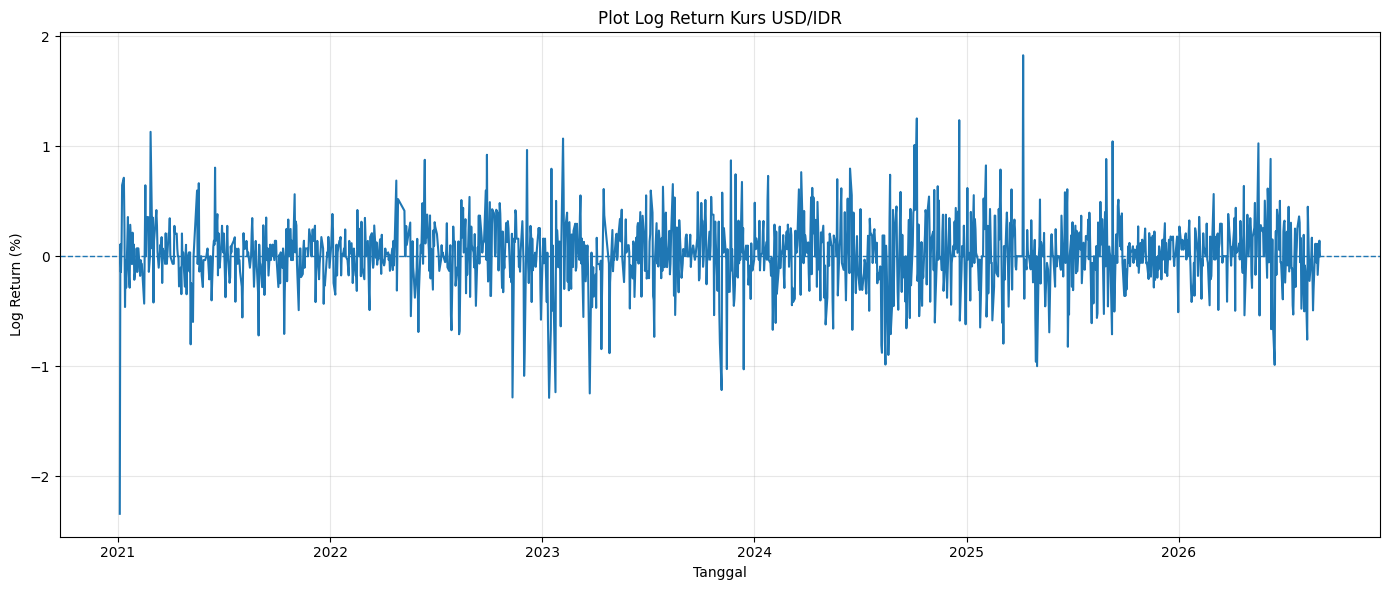

In [12]:
# Membuat Grafik Plot Log Return
plt.figure(figsize=(14, 6))

plt.plot(
    kurs_return['Tanggal'],
    kurs_return['Return']
)

plt.axhline(
    y=0,
    linestyle='--',
    linewidth=1
)

plt.title('Plot Log Return Kurs USD/IDR')
plt.xlabel('Tanggal')
plt.ylabel('Log Return (%)')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Uji Stasioneritas Data
Hipotesisnya:

- $H_0$ : data memiliki unit root / tidak stasioner
- $H_1$ :data tidak memiliki unit root / stasioner

Keputusan:

- p-value < 0.05 → tolak $H_0$ → return stasioner
- p-value ≥ 0.05 → gagal tolak $H_0$ → return belum stasioner




In [13]:
# Uji Stasioneritas ADF
from statsmodels.tsa.stattools import adfuller

adf = adfuller(kurs_return['Return'])

print('ADF Statistic :', adf[0])
print('p-value       :', adf[1])
print('Critical Values:')

for key, value in adf[4].items():
    print(f'   {key}: {value}')

ADF Statistic : -13.661078771248746
p-value       : 1.521020137874348e-25
Critical Values:
   1%: -3.434918371231736
   5%: -2.8635576234668982
   10%: -2.5678441693558898


/tmp/ipykernel_1334/3127811082.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf = adfuller(kurs_return['Return'])


Berdasarkan uji Augmented Dickey-Fuller (ADF), diperoleh nilai statistik ADF sebesar -13.661 dengan p-value sebesar $1{.}52 \times 10^{-25}$. Karena p-value lebih kecil dari taraf signifikansi 5%, maka $H_0$ ditolak. Dengan demikian, data log return kurs USD/IDR telah stasioner.

## Plot ACF dan PACF dari Data Log Return
ACF dan PACF sdigunakan untuk melihat apakah masih terdapat pola autokorelasi pada rata-rata return dan membantu menentukan kandidat orde ARMA(p,q).

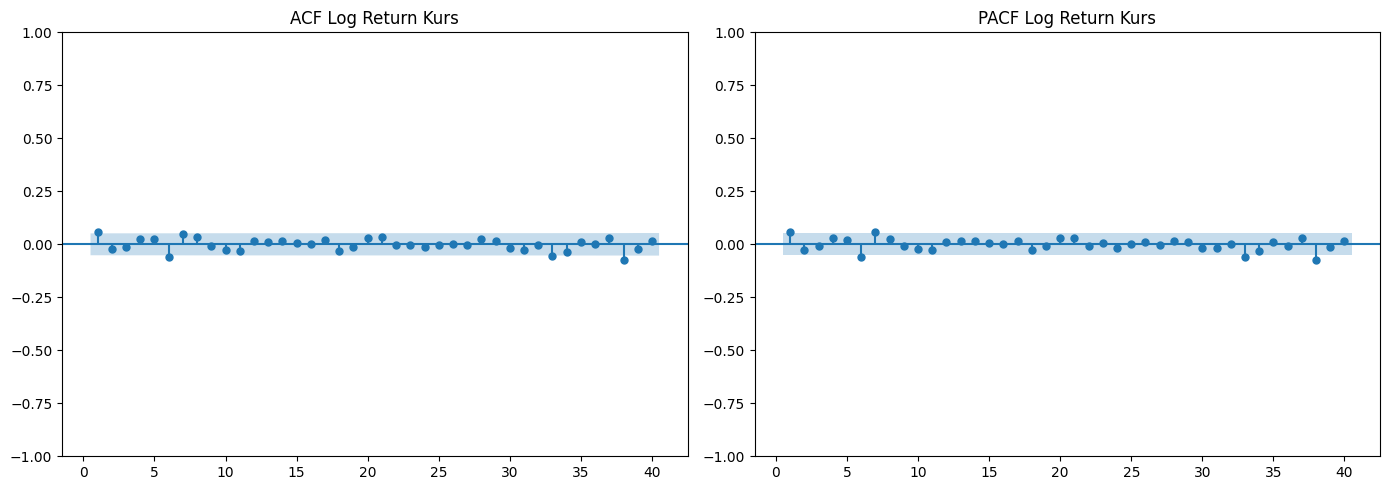

In [14]:
# Plot ACF dan PACF data log return
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# ACF
plot_acf(
    kurs_return['Return'],
    lags=40,
    zero=False,
    ax=ax[0]
)
ax[0].set_title('ACF Log Return Kurs')

# PACF
plot_pacf(
    kurs_return['Return'],
    lags=40,
    zero=False,
    method='ywm',
    ax=ax[1]
)
ax[1].set_title('PACF Log Return Kurs')

plt.tight_layout()
plt.show()

Plot ACF dan PACF log return kurs tidak menunjukkan pola cut off maupun tails off yang jelas, sehingga ketergantungan linear pada rata-rata return relatif lemah dan kandidat model ARMA berorde rendah seperti ARMA(0,0), ARMA(1,0), ARMA(0,1), dan ARMA(1,1) akan digunakan.

## Estimasi Kandidat ARMA

In [15]:
from statsmodels.tsa.arima.model import ARIMA

# ARMA(0,0)
model_00 = ARIMA(
    kurs_return['Return'],
    order=(0, 0, 0)
).fit()

# ARMA(1,0)
model_10 = ARIMA(
    kurs_return['Return'],
    order=(1, 0, 0)
).fit()

# ARMA(0,1)
model_01 = ARIMA(
    kurs_return['Return'],
    order=(0, 0, 1)
).fit()

# ARMA(1,1)
model_11 = ARIMA(
    kurs_return['Return'],
    order=(1, 0, 1)
).fit()

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use on the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use on the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use on the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generate

In [16]:
# Bandingkan Nilai AIC/BIC
import pandas as pd

perbandingan_arma = pd.DataFrame({
    'Model': [
        'ARMA(0,0)',
        'ARMA(1,0)',
        'ARMA(0,1)',
        'ARMA(1,1)'
    ],
    'AIC': [
        model_00.aic,
        model_10.aic,
        model_01.aic,
        model_11.aic
    ],
    'BIC': [
        model_00.bic,
        model_10.bic,
        model_01.bic,
        model_11.bic
    ]
})

perbandingan_arma

,Model,AIC,BIC
0,"ARMA(0,0)",792.377463,802.923648
1,"ARMA(1,0)",788.957138,804.776416
2,"ARMA(0,1)",788.695558,804.514836
3,"ARMA(1,1)",790.355930,811.448301


Berdasarkan nilai AIC, model ARMA(0,1) memberikan nilai terkecil sebesar 788.696, sedangkan berdasarkan BIC model ARMA(0,0) memberikan nilai terkecil sebesar 802.924, sehingga pemilihan model selanjutnya perlu mempertimbangkan signifikansi parameter dan hasil diagnostik residual.

In [17]:
# Signifikansi Parameter ARMA (0,1)
print(model_01.summary())

                               SARIMAX Results                                
Dep. Variable:                 Return   No. Observations:                 1441
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -391.348
Date:                Sat, 19 Sep 2026   AIC                            788.696
Time:                        09:24:23   BIC                            804.515
Sample:                             0   HQIC                           794.601
                               - 1441                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0152      0.009      1.676      0.094      -0.003       0.033
ma.L1          0.0654      0.023      2.855      0.004       0.020       0.110
sigma2         0.1008      0.002     46.043      0.0

In [18]:
# Signifikansi Parameter ARMA (1,0)
print(model_10.summary())

                               SARIMAX Results                                
Dep. Variable:                 Return   No. Observations:                 1441
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -391.479
Date:                Sat, 19 Sep 2026   AIC                            788.957
Time:                        09:25:07   BIC                            804.776
Sample:                             0   HQIC                           794.862
                               - 1441                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0152      0.009      1.673      0.094      -0.003       0.033
ar.L1          0.0625      0.022      2.780      0.005       0.018       0.106
sigma2         0.1008      0.002     45.980      0.0

Berdasarkan signifikansi parameter serta nilai AIC dan BIC, ARMA(0,1) dipilih sebagai kandidat model mean karena parameter MA(1) signifikan pada taraf 5% dan menghasilkan nilai AIC dan BIC yang lebih kecil dibandingkan ARMA(1,0).

## Diagnostic Checking ARMA(0,1)

Hipotesis:

- $H_0$ : tidak terdapat autokorelasi residual
- $H_1$ : terdapat autokorelasi residual

Jika seluruh atau sebagian besar $p\text{-value}>0{.}05$, berarti model mean sudah cukup baik dalam menangkap autokorelasi.

In [19]:
# uji autokorelasi residual pada beberapa lag
from statsmodels.stats.diagnostic import acorr_ljungbox

residual = model_01.resid

ljung_box = acorr_ljungbox(
    residual,
    lags=[5, 10, 15, 20],
    return_df=True
)

ljung_box

,lb_stat,lb_pvalue
5,2.773800,0.734810
10,15.053059,0.130139
15,17.206111,0.306693
20,20.825571,0.407463


Berdasarkan uji Ljung-Box pada lag 5, 10, 15, dan 20, seluruh p-value lebih besar dari 0.05 sehingga tidak terdapat autokorelasi yang signifikan pada residual model ARMA(0,1). Dengan kata lain, model sudah cukup baik menangkap pola ketergantungan linear pada rata-rata return.

## Uji Normalitas Residual

Metode uji yang digunakan yaitu Jarque-Bera, dengan hipotesis:

- $H_0$ : residual berdistribusi normal
- $H_1$ : residual tidak berdistribusi normal

Keputusan:

$$ p{-value}<0{.}05 $$

maka residual tidak berdistribusi normal.

In [20]:
from scipy.stats import jarque_bera

jb_stat, jb_pvalue = jarque_bera(residual)

print('Jarque-Bera Statistic :', jb_stat)
print('p-value               :', jb_pvalue)

Jarque-Bera Statistic : 1093.7782060900572
p-value               : 3.083758322105201e-238


Berdasarkan uji Jarque–Bera, diperoleh p-value sebesar $3{.}08\times10^{-238}$, yang lebih kecil dari 0.05, sehingga $H_0$ ditolak dan residual model ARMA(0,1) dinyatakan tidak berdistribusi normal. Hasil ketidaknormalan justru cukup lazim dan tidak menghalangi pemodelan GARCH.

## Uji ARCH-LM
Hipotesisnya:

- $H_0$ : tidak terdapat efek ARCH pada residual
- $H_1$ : terdapat efek ARCH pada residual

Kriterianya:

- jika $p{-value} < 0{.}05$ → tolak $H_0$ → ada efek ARCH
- jika $p{-value} \ge 0{.}05$ → gagal tolak $H_0$ → tidak ada efek ARCH

Yang perlu diperhatikan biasanya LM p-value.

In [21]:
from statsmodels.stats.diagnostic import het_arch

arch_test = het_arch(residual, nlags=12)

print('LM Statistic  :', arch_test[0])
print('LM p-value    :', arch_test[1])
print('F Statistic   :', arch_test[2])
print('F p-value     :', arch_test[3])

LM Statistic  : 42.14102954368681
LM p-value    : 3.153358543489596e-05
F Statistic   : 3.585542288066183
F p-value     : 2.7061632160255665e-05


/usr/local/lib/python3.13/dist-packages/statsmodels/stats/diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


Berdasarkan uji ARCH-LM dengan 12 lag, diperoleh p-value sebesar $3{.}15\times10^{-5}$, yang lebih kecil dari 0.05, sehingga $H_0$ ditolak dan residual model ARMA(0,1) terbukti mengandung efek ARCH atau heteroskedastisitas bersyarat.

Ini berarti penggunaan model ARCH/GARCH memang relevan untuk data kurs ini.

## Plot ACF dan PACF dari Residual Kuadrat

Tujuannya untuk melihat apakah masih ada pola ketergantungan pada varians residual dan membantu memberi kandidat awal orde ARCH/GARCH.

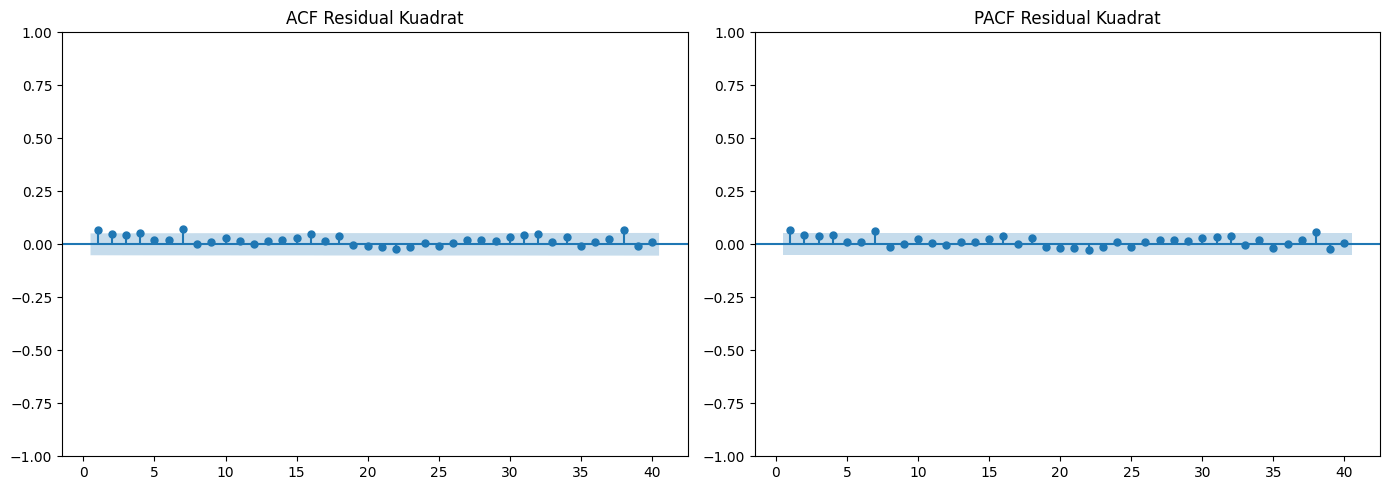

In [22]:
# Residual kuadrat
residual_sq = residual**2

# Plot ACF dan PACF residual kuadrat
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(
    residual_sq,
    lags=40,
    zero=False,
    ax=ax[0]
)
ax[0].set_title('ACF Residual Kuadrat')

plot_pacf(
    residual_sq,
    lags=40,
    zero=False,
    method='ywm',
    ax=ax[1]
)
ax[1].set_title('PACF Residual Kuadrat')

plt.tight_layout()
plt.show()